In [1]:
import pandas as pd

In [2]:
ghs = pd.read_csv("Global Health Statistics.csv")

In [3]:
ghs.head()

,Country,Year,Disease Name,Disease Category,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Age Group,Gender,Population Affected,...,Hospital Beds per 1000,Treatment Type,Average Treatment Cost (USD),Availability of Vaccines/Treatment,Recovery Rate (%),DALYs,Improvement in 5 Years (%),Per Capita Income (USD),Education Index,Urbanization Rate (%)
0,Italy,2013,Malaria,Respiratory,0.95,1.55,8.42,0-18,Male,471007,...,7.58,Medication,21064,No,91.82,4493,2.16,16886,0.79,86.02
1,France,2002,Ebola,Parasitic,12.46,8.63,8.75,61+,Male,634318,...,5.11,Surgery,47851,Yes,76.65,2366,4.82,80639,0.74,45.52
2,Turkey,2015,COVID-19,Genetic,0.91,2.35,6.22,36-60,Male,154878,...,3.49,Vaccination,27834,Yes,98.55,41,5.81,12245,0.41,40.20
3,Indonesia,2011,Parkinson's Disease,Autoimmune,4.68,6.29,3.99,0-18,Other,446224,...,8.44,Surgery,144,Yes,67.35,3201,2.22,49336,0.49,58.47
4,Italy,2013,Tuberculosis,Genetic,0.83,13.59,7.01,61+,Male,472908,...,5.90,Medication,8908,Yes,50.06,2832,6.93,47701,0.50,48.14


In [4]:
ghs['Disease Name'].value_counts(dropna=False)

Disease Name
COVID-19               50404
Zika                   50313
Dengue                 50289
Cancer                 50285
HIV/AIDS               50274
Cholera                50249
Asthma                 50122
Leprosy                50064
Diabetes               50020
Rabies                 49975
Hepatitis              49970
Polio                  49956
Malaria                49948
Influenza              49919
Tuberculosis           49862
Alzheimer's Disease    49823
Measles                49736
Parkinson's Disease    49708
Ebola                  49692
Hypertension           49391
Name: count, dtype: int64

In [5]:
ghs['Country'].value_counts(dropna=False)

Country
Russia          50532
South Africa    50408
South Korea     50181
Germany         50176
UK              50125
Canada          50114
Mexico          50080
China           50066
Nigeria         50046
Saudi Arabia    49958
Australia       49953
France          49943
USA             49913
Turkey          49901
Italy           49839
Argentina       49798
Japan           49764
India           49760
Indonesia       49756
Brazil          49687
Name: count, dtype: int64

In [6]:
counts = ghs.groupby('Country')['Disease Name'].value_counts()

In [7]:
counts

Country    Disease Name       
Argentina  COVID-19               2600
           Influenza              2576
           Asthma                 2550
           Tuberculosis           2543
           Measles                2535
                                  ... 
USA        Parkinson's Disease    2478
           Dengue                 2470
           Tuberculosis           2470
           Measles                2434
           Hypertension           2429
Name: count, Length: 400, dtype: int64

In [8]:
# So it looks like this data set has been smoothed out so each country has approximately the
# same number of each disease, and the diseases and countries have the data evenly distributed
# between them.  

In [9]:
# At this point, since each country is approximately even, I will just choose a couple to 
# make some observations.  I will observe the United States and Nigeria.

In [10]:
# First I have to fix a couple things for further down the road to allow the Decision Tree to
# work. 

In [11]:
ghs['Age Group'].value_counts(dropna=False)

Age Group
19-35    251201
61+      249989
0-18     249605
36-60    249205
Name: count, dtype: int64

In [12]:
ghs['Treatment Type'].value_counts(dropna=False)

Treatment Type
Surgery        250528
Therapy        250263
Vaccination    249753
Medication     249456
Name: count, dtype: int64

In [13]:
encoded_ghs = pd.get_dummies(ghs, columns = ['Age Group','Gender', 'Treatment Type'])

In [14]:
encoded_ghs.head()

,Country,Year,Disease Name,Disease Category,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Population Affected,Healthcare Access (%),Doctors per 1000,...,Age Group_19-35,Age Group_36-60,Age Group_61+,Gender_Female,Gender_Male,Gender_Other,Treatment Type_Medication,Treatment Type_Surgery,Treatment Type_Therapy,Treatment Type_Vaccination
0,Italy,2013,Malaria,Respiratory,0.95,1.55,8.42,471007,57.74,3.34,...,False,False,False,False,True,False,True,False,False,False
1,France,2002,Ebola,Parasitic,12.46,8.63,8.75,634318,89.21,1.33,...,False,False,True,False,True,False,False,True,False,False
2,Turkey,2015,COVID-19,Genetic,0.91,2.35,6.22,154878,56.41,4.07,...,False,True,False,False,True,False,False,False,False,True
3,Indonesia,2011,Parkinson's Disease,Autoimmune,4.68,6.29,3.99,446224,85.20,3.18,...,False,False,False,False,False,True,False,True,False,False
4,Italy,2013,Tuberculosis,Genetic,0.83,13.59,7.01,472908,67.00,4.61,...,False,False,True,False,True,False,True,False,False,False


In [15]:
mapping = {'Yes': 1, 'No': 2}

In [16]:
ghs = encoded_ghs.replace(mapping)

C:\Users\jabbe\AppData\Local\Temp\ipykernel_19904\343164843.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ghs = encoded_ghs.replace(mapping)


In [17]:
ghs.head()

,Country,Year,Disease Name,Disease Category,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Population Affected,Healthcare Access (%),Doctors per 1000,...,Age Group_19-35,Age Group_36-60,Age Group_61+,Gender_Female,Gender_Male,Gender_Other,Treatment Type_Medication,Treatment Type_Surgery,Treatment Type_Therapy,Treatment Type_Vaccination
0,Italy,2013,Malaria,Respiratory,0.95,1.55,8.42,471007,57.74,3.34,...,False,False,False,False,True,False,True,False,False,False
1,France,2002,Ebola,Parasitic,12.46,8.63,8.75,634318,89.21,1.33,...,False,False,True,False,True,False,False,True,False,False
2,Turkey,2015,COVID-19,Genetic,0.91,2.35,6.22,154878,56.41,4.07,...,False,True,False,False,True,False,False,False,False,True
3,Indonesia,2011,Parkinson's Disease,Autoimmune,4.68,6.29,3.99,446224,85.20,3.18,...,False,False,False,False,False,True,False,True,False,False
4,Italy,2013,Tuberculosis,Genetic,0.83,13.59,7.01,472908,67.00,4.61,...,False,False,True,False,True,False,True,False,False,False


In [18]:
ghs[(ghs['Country'] == 'USA') & (ghs['Disease Name'] == 'Zika')].head()

,Country,Year,Disease Name,Disease Category,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Population Affected,Healthcare Access (%),Doctors per 1000,...,Age Group_19-35,Age Group_36-60,Age Group_61+,Gender_Female,Gender_Male,Gender_Other,Treatment Type_Medication,Treatment Type_Surgery,Treatment Type_Therapy,Treatment Type_Vaccination
1206,USA,2003,Zika,Respiratory,15.65,1.28,6.17,278033,90.58,3.82,...,False,False,True,False,False,True,False,True,False,False
1370,USA,2024,Zika,Metabolic,6.70,4.73,7.54,679583,78.37,1.12,...,False,False,True,False,True,False,False,True,False,False
1570,USA,2004,Zika,Metabolic,12.27,2.65,8.92,833136,51.29,3.57,...,False,False,False,False,True,False,True,False,False,False
1803,USA,2016,Zika,Respiratory,7.84,2.14,9.24,455944,89.15,4.44,...,False,False,True,False,False,True,False,False,False,True
1809,USA,2015,Zika,Infectious,11.81,14.80,2.28,251694,59.38,2.88,...,False,False,False,False,False,True,False,False,True,False


In [19]:
ghs_us = ghs[ghs['Country'] == 'USA']
ghs_nigeria = ghs[ghs['Country'] == 'Nigeria']

In [20]:
ghs_us.head()

,Country,Year,Disease Name,Disease Category,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Population Affected,Healthcare Access (%),Doctors per 1000,...,Age Group_19-35,Age Group_36-60,Age Group_61+,Gender_Female,Gender_Male,Gender_Other,Treatment Type_Medication,Treatment Type_Surgery,Treatment Type_Therapy,Treatment Type_Vaccination
6,USA,2013,Malaria,Cardiovascular,18.42,6.33,9.33,289931,90.03,3.16,...,False,False,True,True,False,False,False,True,False,False
15,USA,2024,Dengue,Viral,1.82,2.98,7.01,623844,96.83,0.56,...,False,True,False,True,False,False,True,False,False,False
24,USA,2000,Asthma,Metabolic,7.91,9.13,1.58,365955,64.87,1.28,...,False,False,False,False,True,False,False,False,True,False
57,USA,2011,Dengue,Chronic,10.45,11.76,5.57,87481,99.11,2.64,...,False,True,False,False,True,False,False,False,True,False
72,USA,2002,Hepatitis,Respiratory,7.13,6.96,4.02,251611,53.40,2.28,...,False,False,True,False,False,True,False,False,True,False


In [21]:
ghs_nigeria.head()

,Country,Year,Disease Name,Disease Category,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Population Affected,Healthcare Access (%),Doctors per 1000,...,Age Group_19-35,Age Group_36-60,Age Group_61+,Gender_Female,Gender_Male,Gender_Other,Treatment Type_Medication,Treatment Type_Surgery,Treatment Type_Therapy,Treatment Type_Vaccination
7,Nigeria,2007,Tuberculosis,Neurological,3.48,5.71,1.21,393296,75.60,0.54,...,False,False,False,True,False,False,True,False,False,False
12,Nigeria,2007,Diabetes,Infectious,8.92,13.19,5.52,227849,84.41,1.37,...,False,True,False,True,False,False,False,False,True,False
16,Nigeria,2009,Leprosy,Parasitic,15.18,14.95,8.21,788926,87.33,3.96,...,False,False,False,False,True,False,False,False,False,True
51,Nigeria,2002,Measles,Neurological,3.49,14.00,6.61,786558,58.08,4.73,...,False,True,False,False,True,False,False,False,False,True
64,Nigeria,2010,Diabetes,Cardiovascular,18.17,6.20,2.12,985553,88.65,3.82,...,True,False,False,True,False,False,False,False,True,False


In [22]:
ghs.columns

Index(['Country', 'Year', 'Disease Name', 'Disease Category',
       'Prevalence Rate (%)', 'Incidence Rate (%)', 'Mortality Rate (%)',
       'Population Affected', 'Healthcare Access (%)', 'Doctors per 1000',
       'Hospital Beds per 1000', 'Average Treatment Cost (USD)',
       'Availability of Vaccines/Treatment', 'Recovery Rate (%)', 'DALYs',
       'Improvement in 5 Years (%)', 'Per Capita Income (USD)',
       'Education Index', 'Urbanization Rate (%)', 'Age Group_0-18',
       'Age Group_19-35', 'Age Group_36-60', 'Age Group_61+', 'Gender_Female',
       'Gender_Male', 'Gender_Other', 'Treatment Type_Medication',
       'Treatment Type_Surgery', 'Treatment Type_Therapy',
       'Treatment Type_Vaccination'],
      dtype='object')

In [23]:
# I will choose zika for each country only to simplify the data frame.

In [24]:
ghs_us_zika = ghs_us[ghs_us['Disease Name'] == 'Zika']
ghs_nigeria_zika = ghs_nigeria[ghs_nigeria['Disease Name'] == 'Zika']

In [25]:
ghs_us_zika

,Country,Year,Disease Name,Disease Category,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Population Affected,Healthcare Access (%),Doctors per 1000,...,Age Group_19-35,Age Group_36-60,Age Group_61+,Gender_Female,Gender_Male,Gender_Other,Treatment Type_Medication,Treatment Type_Surgery,Treatment Type_Therapy,Treatment Type_Vaccination
1206,USA,2003,Zika,Respiratory,15.65,1.28,6.17,278033,90.58,3.82,...,False,False,True,False,False,True,False,True,False,False
1370,USA,2024,Zika,Metabolic,6.70,4.73,7.54,679583,78.37,1.12,...,False,False,True,False,True,False,False,True,False,False
1570,USA,2004,Zika,Metabolic,12.27,2.65,8.92,833136,51.29,3.57,...,False,False,False,False,True,False,True,False,False,False
1803,USA,2016,Zika,Respiratory,7.84,2.14,9.24,455944,89.15,4.44,...,False,False,True,False,False,True,False,False,False,True
1809,USA,2015,Zika,Infectious,11.81,14.80,2.28,251694,59.38,2.88,...,False,False,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999733,USA,2015,Zika,Genetic,13.38,0.96,9.85,70379,51.28,0.88,...,False,False,False,True,False,False,True,False,False,False
999778,USA,2002,Zika,Bacterial,13.54,1.60,9.31,544055,76.33,0.54,...,True,False,False,False,True,False,False,False,True,False
999793,USA,2023,Zika,Autoimmune,6.07,6.31,6.68,182014,88.28,2.85,...,False,False,False,False,False,True,False,True,False,False
999953,USA,2003,Zika,Metabolic,13.48,3.14,3.64,338610,64.86,2.93,...,False,True,False,False,True,False,False,False,False,True


In [26]:
ghs_us_zika.drop(columns=['Country', 'Disease Name', 'Disease Category'], inplace=True)
ghs_nigeria_zika.drop(columns=['Country', 'Disease Name', 'Disease Category'], inplace=True)

C:\Users\jabbe\AppData\Local\Temp\ipykernel_19904\3014924869.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ghs_us_zika.drop(columns=['Country', 'Disease Name', 'Disease Category'], inplace=True)
C:\Users\jabbe\AppData\Local\Temp\ipykernel_19904\3014924869.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ghs_nigeria_zika.drop(columns=['Country', 'Disease Name', 'Disease Category'], inplace=True)


In [27]:
ghs_us_zika.head()

,Year,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Population Affected,Healthcare Access (%),Doctors per 1000,Hospital Beds per 1000,Average Treatment Cost (USD),Availability of Vaccines/Treatment,...,Age Group_19-35,Age Group_36-60,Age Group_61+,Gender_Female,Gender_Male,Gender_Other,Treatment Type_Medication,Treatment Type_Surgery,Treatment Type_Therapy,Treatment Type_Vaccination
1206,2003,15.65,1.28,6.17,278033,90.58,3.82,7.79,23284,2,...,False,False,True,False,False,True,False,True,False,False
1370,2024,6.70,4.73,7.54,679583,78.37,1.12,2.57,26637,2,...,False,False,True,False,True,False,False,True,False,False
1570,2004,12.27,2.65,8.92,833136,51.29,3.57,2.47,44596,1,...,False,False,False,False,True,False,True,False,False,False
1803,2016,7.84,2.14,9.24,455944,89.15,4.44,6.09,26704,2,...,False,False,True,False,False,True,False,False,False,True
1809,2015,11.81,14.80,2.28,251694,59.38,2.88,5.01,15432,2,...,False,False,False,False,False,True,False,False,True,False


<Axes: >

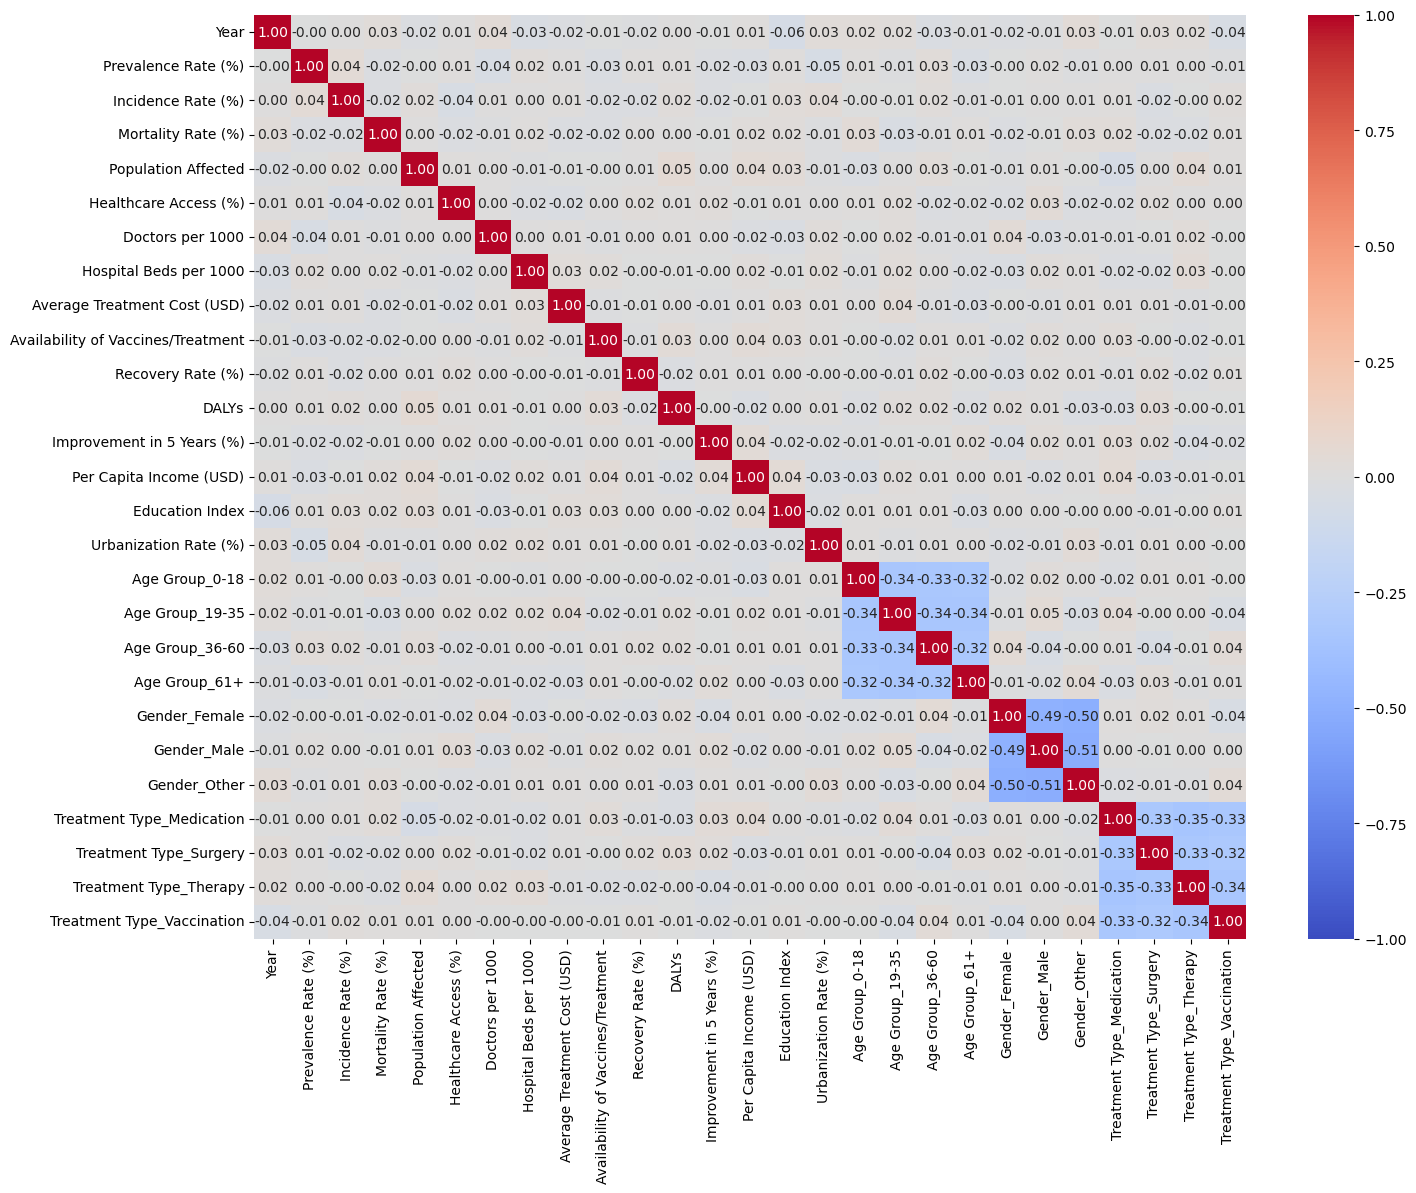

In [28]:
import matplotlib.pyplot as plt
corr_us_zika = ghs_us_zika.corr()
import seaborn as sns

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_us_zika,
    annot=True,        
    fmt=".2f",        
    cmap="coolwarm",  
    vmin=-1, vmax=1,   
)

In [29]:
ghs_nigeria_zika.head()

,Year,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Population Affected,Healthcare Access (%),Doctors per 1000,Hospital Beds per 1000,Average Treatment Cost (USD),Availability of Vaccines/Treatment,...,Age Group_19-35,Age Group_36-60,Age Group_61+,Gender_Female,Gender_Male,Gender_Other,Treatment Type_Medication,Treatment Type_Surgery,Treatment Type_Therapy,Treatment Type_Vaccination
200,2014,19.55,11.39,9.65,808334,95.38,3.05,9.96,10561,2,...,True,False,False,False,True,False,False,False,True,False
270,2000,9.50,14.66,4.95,375401,82.30,3.75,6.98,47533,2,...,False,True,False,False,True,False,False,True,False,False
401,2016,2.62,5.91,8.43,316498,63.97,3.95,1.44,33807,2,...,True,False,False,True,False,False,False,False,False,True
1334,2021,7.42,9.75,5.92,931489,76.85,4.63,8.79,44450,1,...,False,False,False,True,False,False,False,False,False,True
1568,2001,16.67,12.53,9.82,894895,72.57,2.75,4.37,42934,2,...,True,False,False,False,True,False,False,False,True,False


<Axes: >

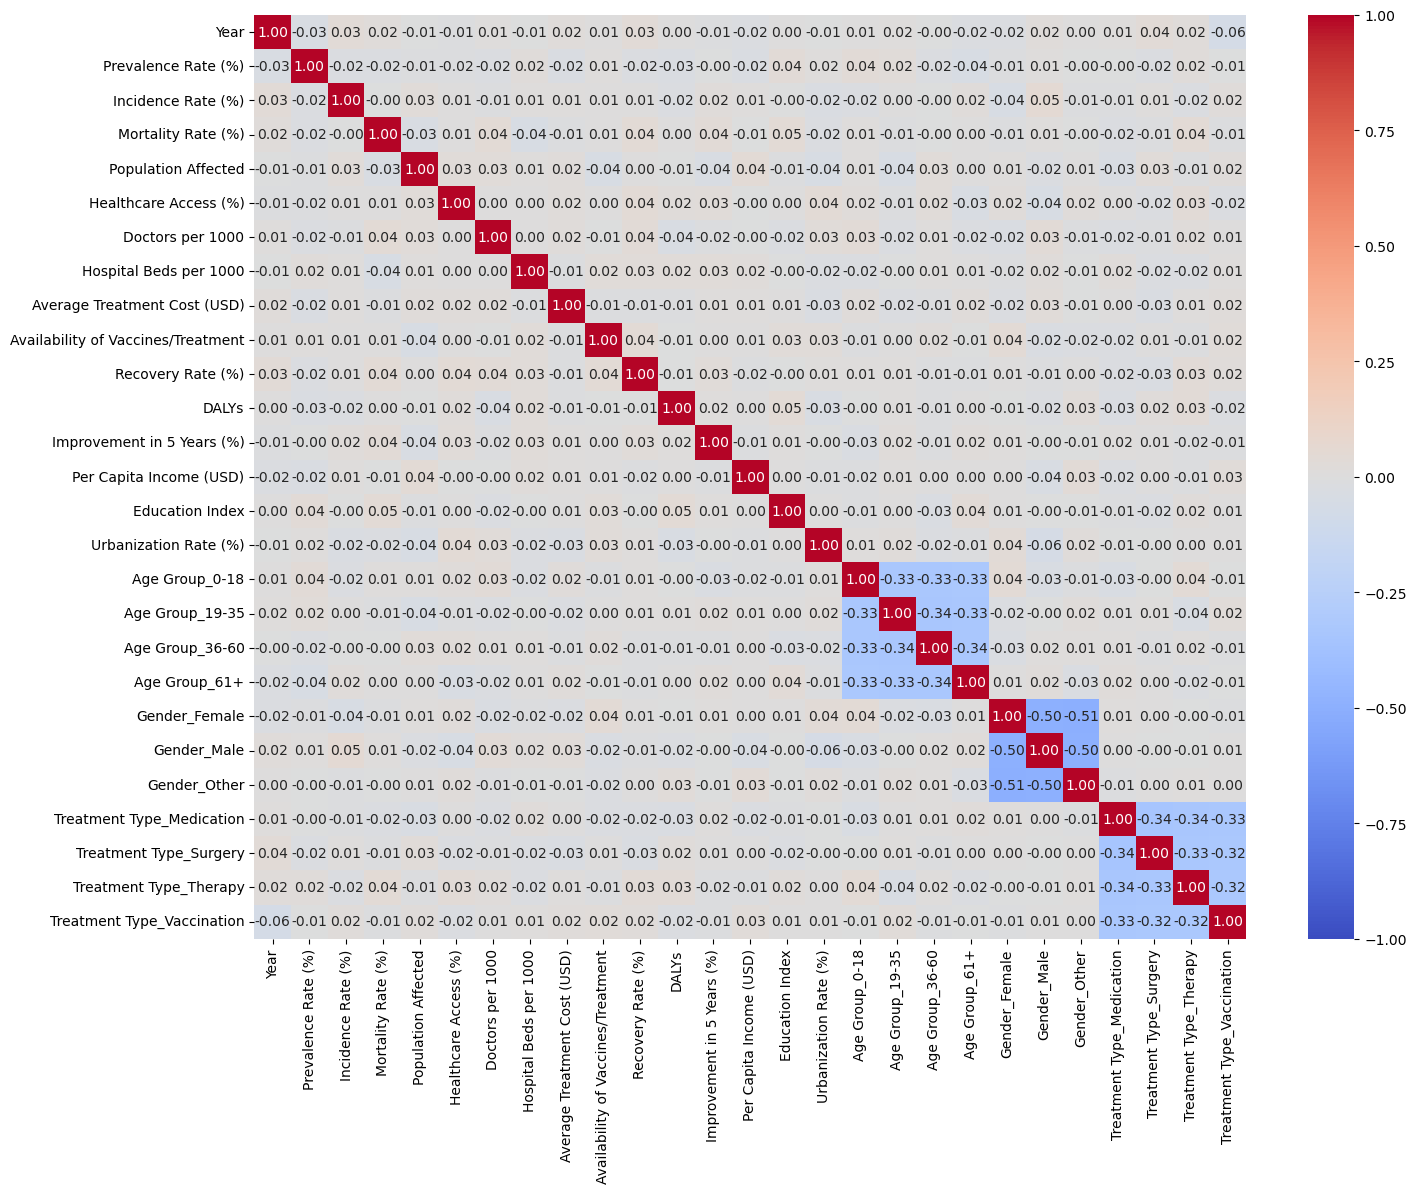

In [30]:
corr_nigeria_zika = ghs_nigeria_zika.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_nigeria_zika,
    annot=True,        
    fmt=".2f",        
    cmap="coolwarm",  
    vmin=-1, vmax=1,   
)

In [31]:
ghs_nigeria_zika['Year'].value_counts(dropna=False)

Year
2016    126
2007    121
2014    120
2022    117
2002    117
2017    115
2011    113
2000    112
2006    109
2018    108
2004    107
2008    103
2020    100
2019    100
2001     99
2009     98
2021     96
2003     95
2013     95
2015     95
2005     95
2023     92
2024     84
2012     83
2010     81
Name: count, dtype: int64

In [32]:
ghs_us_zika['Year'].value_counts(dropna=False)

Year
2006    114
2017    108
2022    107
2021    106
2016    106
2011    105
2014    104
2004    104
2024    103
2001    101
2007    101
2002    100
2000    100
2018     99
2005     99
2003     99
2020     97
2015     96
2013     95
2008     95
2010     95
2023     93
2009     92
2012     86
2019     80
Name: count, dtype: int64

In [33]:
# So, there is no correlation in either data frame with the expection of the dummy variables,
# which is to be expected.  

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [35]:
# So in this model using a decision tree classifier, I will be testing whether the different
# conditions in different years have lead to different incidence rates or mortality rates from 
# Zika in the US and Nigeria.  

In [36]:
# The variables I will be considering are the age group, gender, healthcare access, doctors per
# 1000, hospital beds per 1000, treatment type, average treatment cost (USD), availability of
# vaccines/treatment, per capita income (USD), education index, and urbanization rate.

In [37]:
X_nigeria = ghs_nigeria_zika[['Age Group_0-18', 'Age Group_19-35','Age Group_36-60', 
            'Age Group_61+', 'Gender_Female', 'Gender_Male', 'Gender_Other', 
            'Healthcare Access (%)', 'Doctors per 1000', 'Hospital Beds per 1000', 
            'Treatment Type_Medication', 'Treatment Type_Surgery', 'Treatment Type_Therapy',
            'Treatment Type_Vaccination', 'Average Treatment Cost (USD)', 
            'Availability of Vaccines/Treatment', 'Per Capita Income (USD)', 'Education Index', 
            'Urbanization Rate (%)', 'Population Affected']]

In [38]:
X_us = ghs_us_zika[['Age Group_0-18', 'Age Group_19-35','Age Group_36-60', 
            'Age Group_61+', 'Gender_Female', 'Gender_Male', 'Gender_Other', 
            'Healthcare Access (%)', 'Doctors per 1000', 'Hospital Beds per 1000', 
            'Treatment Type_Medication', 'Treatment Type_Surgery', 'Treatment Type_Therapy',
            'Treatment Type_Vaccination', 'Average Treatment Cost (USD)', 
            'Availability of Vaccines/Treatment', 'Per Capita Income (USD)', 'Education Index', 
            'Urbanization Rate (%)', 'Population Affected']]

In [39]:
y_nigeria_incidence = ghs_nigeria_zika[['Incidence Rate (%)']]
y_nigeria_mortality = ghs_nigeria_zika[['Mortality Rate (%)']]
y_us_incidence = ghs_us_zika[['Incidence Rate (%)']]
y_us_mortality = ghs_us_zika[['Mortality Rate (%)']]

In [40]:
model = DecisionTreeClassifier(
    criterion="gini", 
    max_depth=3)

In [41]:
X_train_nigeria_incidence, X_test_nigeria_incidence, y_train_nigeria_incidence, y_test_nigeria_incidence = train_test_split(
    X_nigeria, y_nigeria_incidence, test_size=0.2)

In [42]:
X_train_nigeria_mortality, X_test_nigeria_mortality, y_train_nigeria_mortality, y_test_nigeria_mortality = train_test_split(
    X_nigeria, y_nigeria_mortality, test_size=0.2)

In [43]:
X_train_us_incidence, X_test_us_incidence, y_train_us_incidence, y_test_us_incidence = train_test_split(
    X_us, y_us_incidence, test_size=0.2)
X_train_us_mortality, X_test_us_mortality, y_train_us_mortality, y_test_us_mortality = train_test_split(
    X_us, y_us_mortality, test_size=0.2)

In [44]:
# Have to use decision tree regressor, let's load that.

In [45]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [46]:
model = DecisionTreeRegressor(max_depth=3)

In [47]:
model.fit(X_train_nigeria_incidence, y_train_nigeria_incidence)

DecisionTreeRegressor(max_depth=3)

In [48]:
y_pred_nigeria_incidence = model.predict(X_test_nigeria_incidence)

In [49]:
from statistics import mean

In [50]:
type(y_pred_nigeria_incidence)

numpy.ndarray

In [51]:
y_pred_nigeria_incidence = pd.DataFrame(y_pred_nigeria_incidence)

In [52]:
y_test_nigeria_incidence.head()

,Incidence Rate (%)
490148,0.70
839082,5.03
31878,11.83
57601,14.71
952802,5.33


In [53]:
y_test_nigeria_incidence = y_test_nigeria_incidence.astype(float)

In [54]:
y_pred_nigeria_incidence = y_pred_nigeria_incidence.astype(float)

In [55]:
y_pred_nigeria_incidence.rename(columns={0: 'Incidence Rate (%)'}, inplace=True)

In [56]:
y_pred_nigeria_incidence.head()

,Incidence Rate (%)
0,7.560790
1,7.560790
2,7.560790
3,6.940384
4,7.560790


In [57]:
y_test_nigeria_incidence.head()

,Incidence Rate (%)
490148,0.70
839082,5.03
31878,11.83
57601,14.71
952802,5.33


In [58]:
y_test_nigeria_incidence = y_test_nigeria_incidence.reset_index(drop=True)

In [59]:
y_test_nigeria_incidence.head()

,Incidence Rate (%)
0,0.70
1,5.03
2,11.83
3,14.71
4,5.33


In [60]:
(y_test_nigeria_incidence - y_pred_nigeria_incidence).head()

,Incidence Rate (%)
0,-6.860790
1,-2.530790
2,4.269210
3,7.769616
4,-2.230790


In [61]:
y_test_nigeria_incidence = y_test_nigeria_incidence.astype(float)
y_pred_nigeria_incidence = y_pred_nigeria_incidence.astype(float)

In [62]:
squared_errors = (y_pred_nigeria_incidence - y_test_nigeria_incidence)**2

In [63]:
squared_errors.head()

,Incidence Rate (%)
0,47.070435
1,6.404896
2,18.226157
3,60.366935
4,4.976422


In [64]:
squared_errors = squared_errors.astype(float)

In [65]:
squared_errors.rename(columns={'Incidence Rate (%)': 0}, inplace=True)

In [66]:
squared_errors.mean(axis=0)

0    19.486833
dtype: float64

In [67]:
mse_nigeria_incidence = ((y_pred_nigeria_incidence - y_test_nigeria_incidence)**2).mean()

In [68]:
mse_nigeria_incidence

Incidence Rate (%)    19.486833
dtype: float64

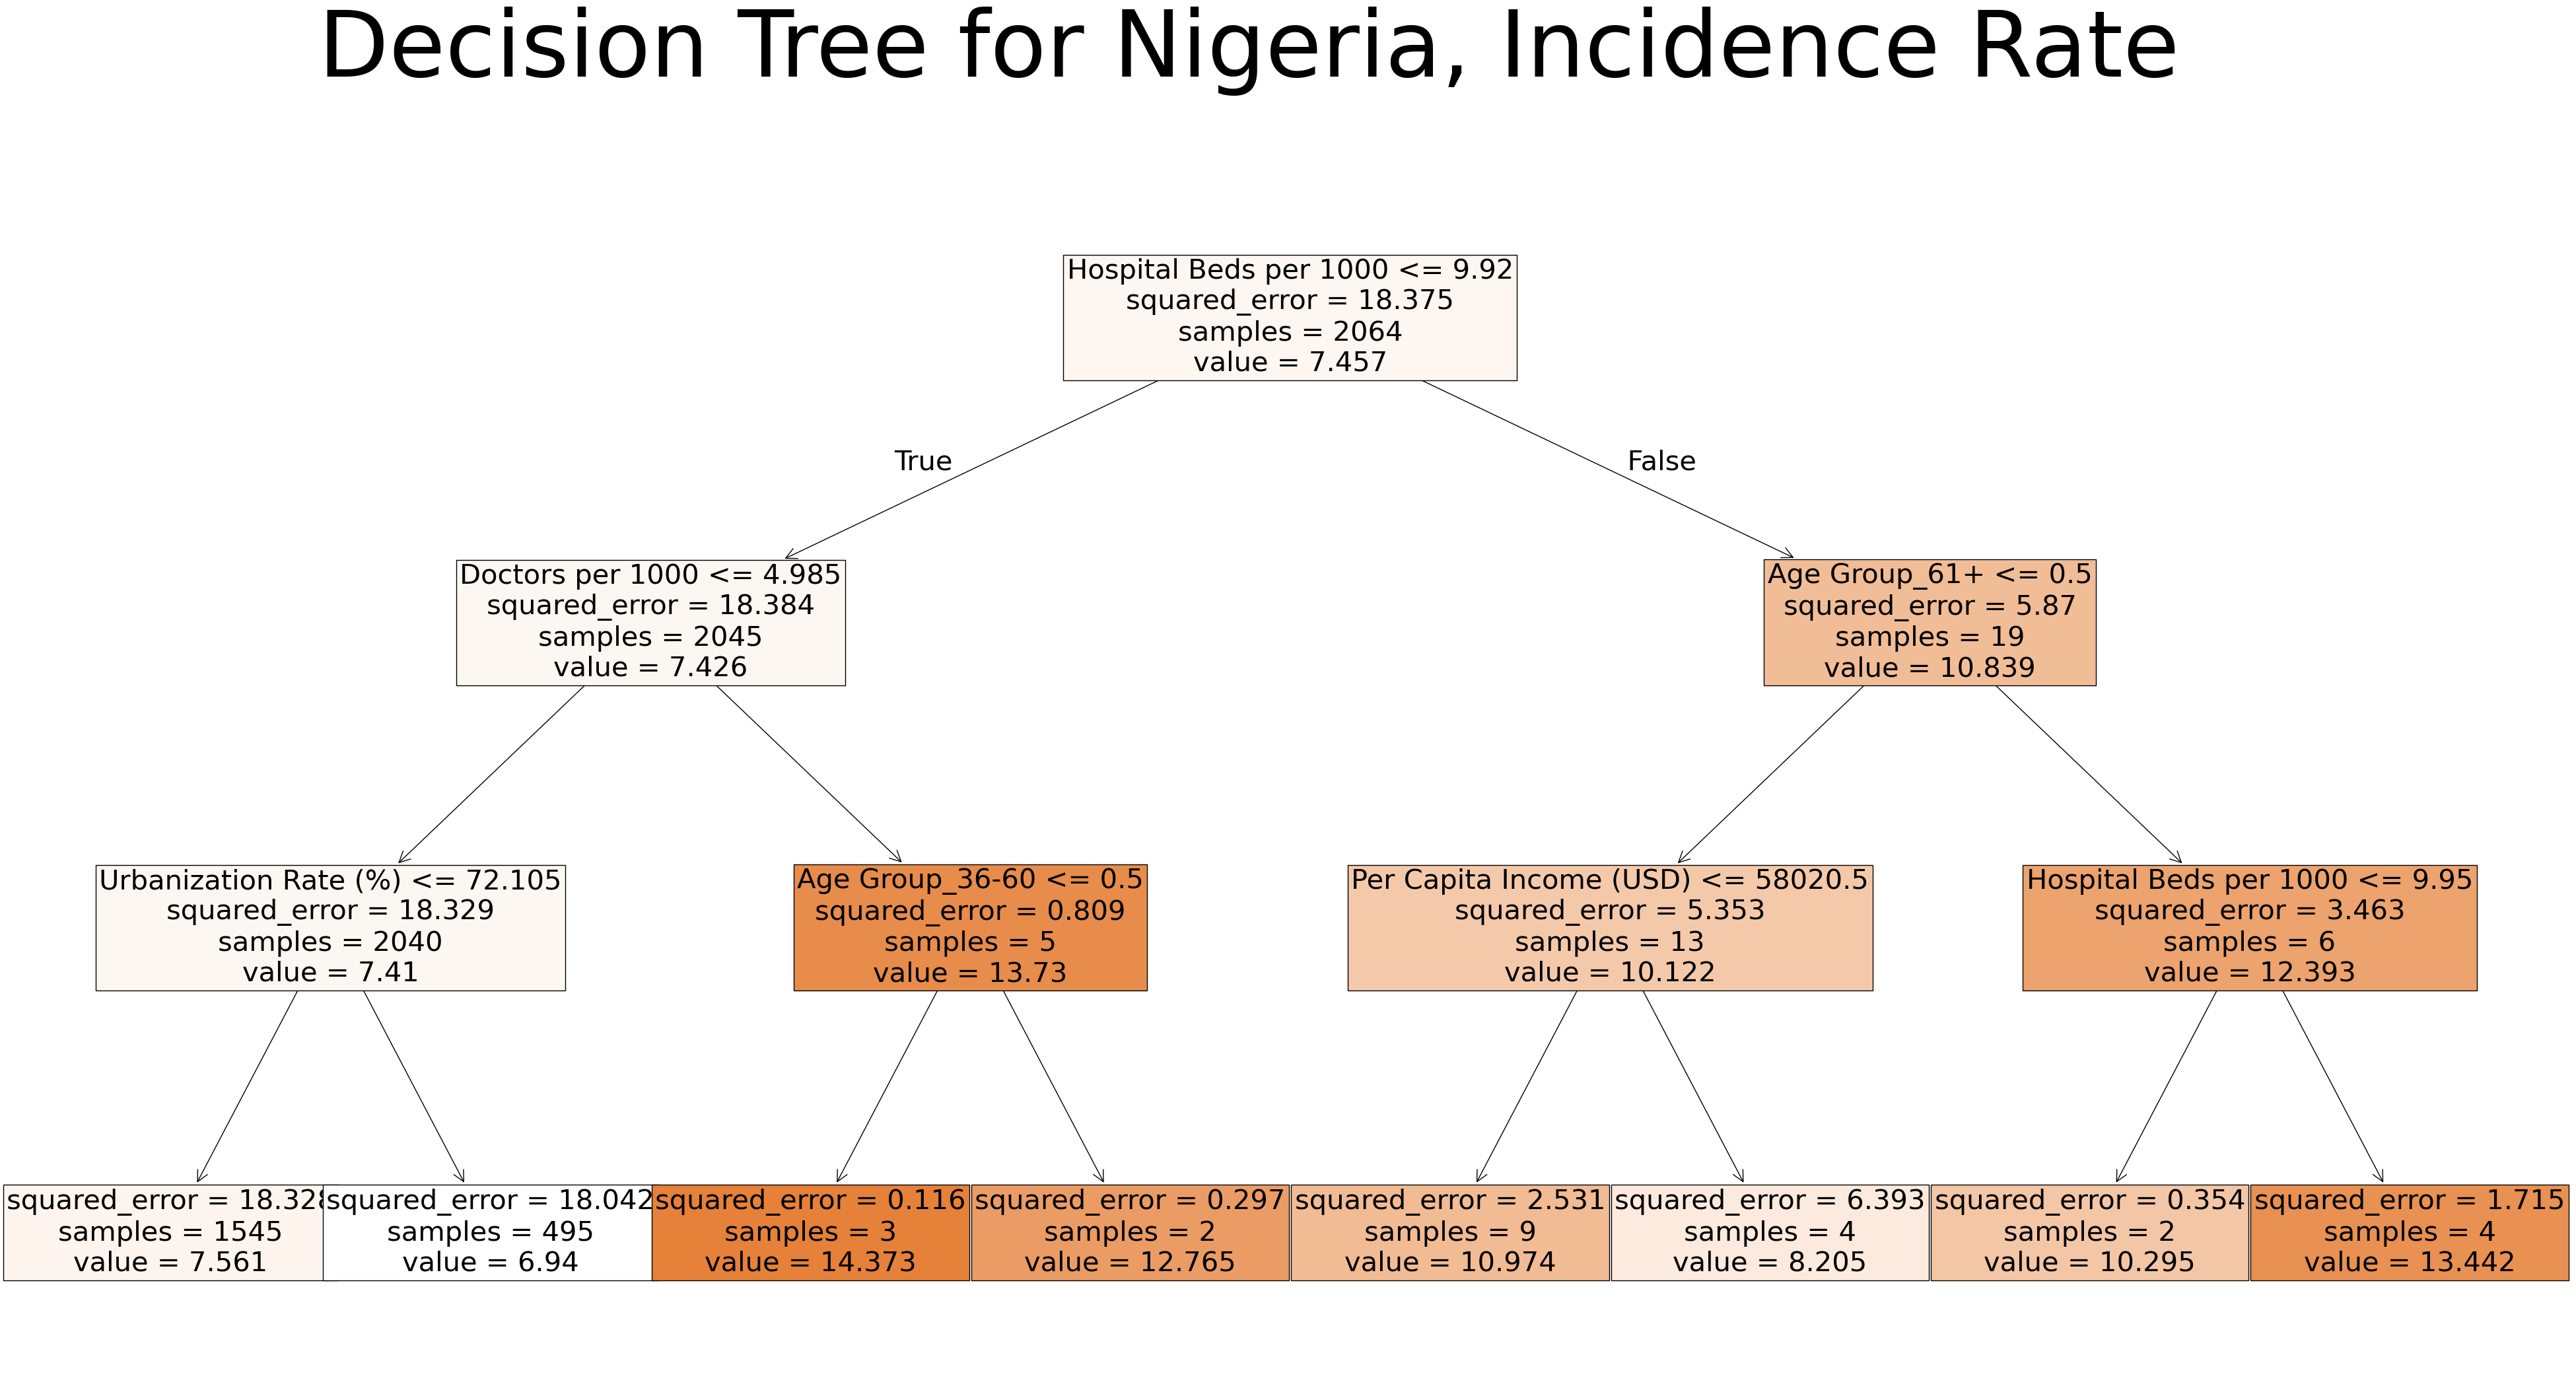

In [69]:
plt.figure(figsize=(50, 24))
plt.suptitle("Decision Tree for Nigeria, Incidence Rate", fontsize=100)
plot_tree(model, feature_names=X_test_nigeria_incidence.columns, fontsize=30, filled=True)
plt.show()

In [70]:
# Ok, now that that's figured out, I can do the rest more quickly.  

In [71]:
model.fit(X_train_nigeria_mortality, y_train_nigeria_mortality)

DecisionTreeRegressor(max_depth=3)

In [72]:
y_pred_nigeria_mortality = model.predict(X_test_nigeria_mortality)

In [73]:
y_pred_nigeria_mortality = pd.DataFrame(y_pred_nigeria_mortality)

In [74]:
y_test_nigeria_mortality = y_test_nigeria_mortality.reset_index(drop=True)

In [75]:
y_pred_nigeria_mortality.rename(columns={0: 'Mortality Rate (%)'}, inplace=True)

In [76]:
mse_nigeria_mortality = ((y_pred_nigeria_mortality - y_test_nigeria_mortality)**2).mean()

In [77]:
mse_nigeria_mortality

Mortality Rate (%)    8.718417
dtype: float64

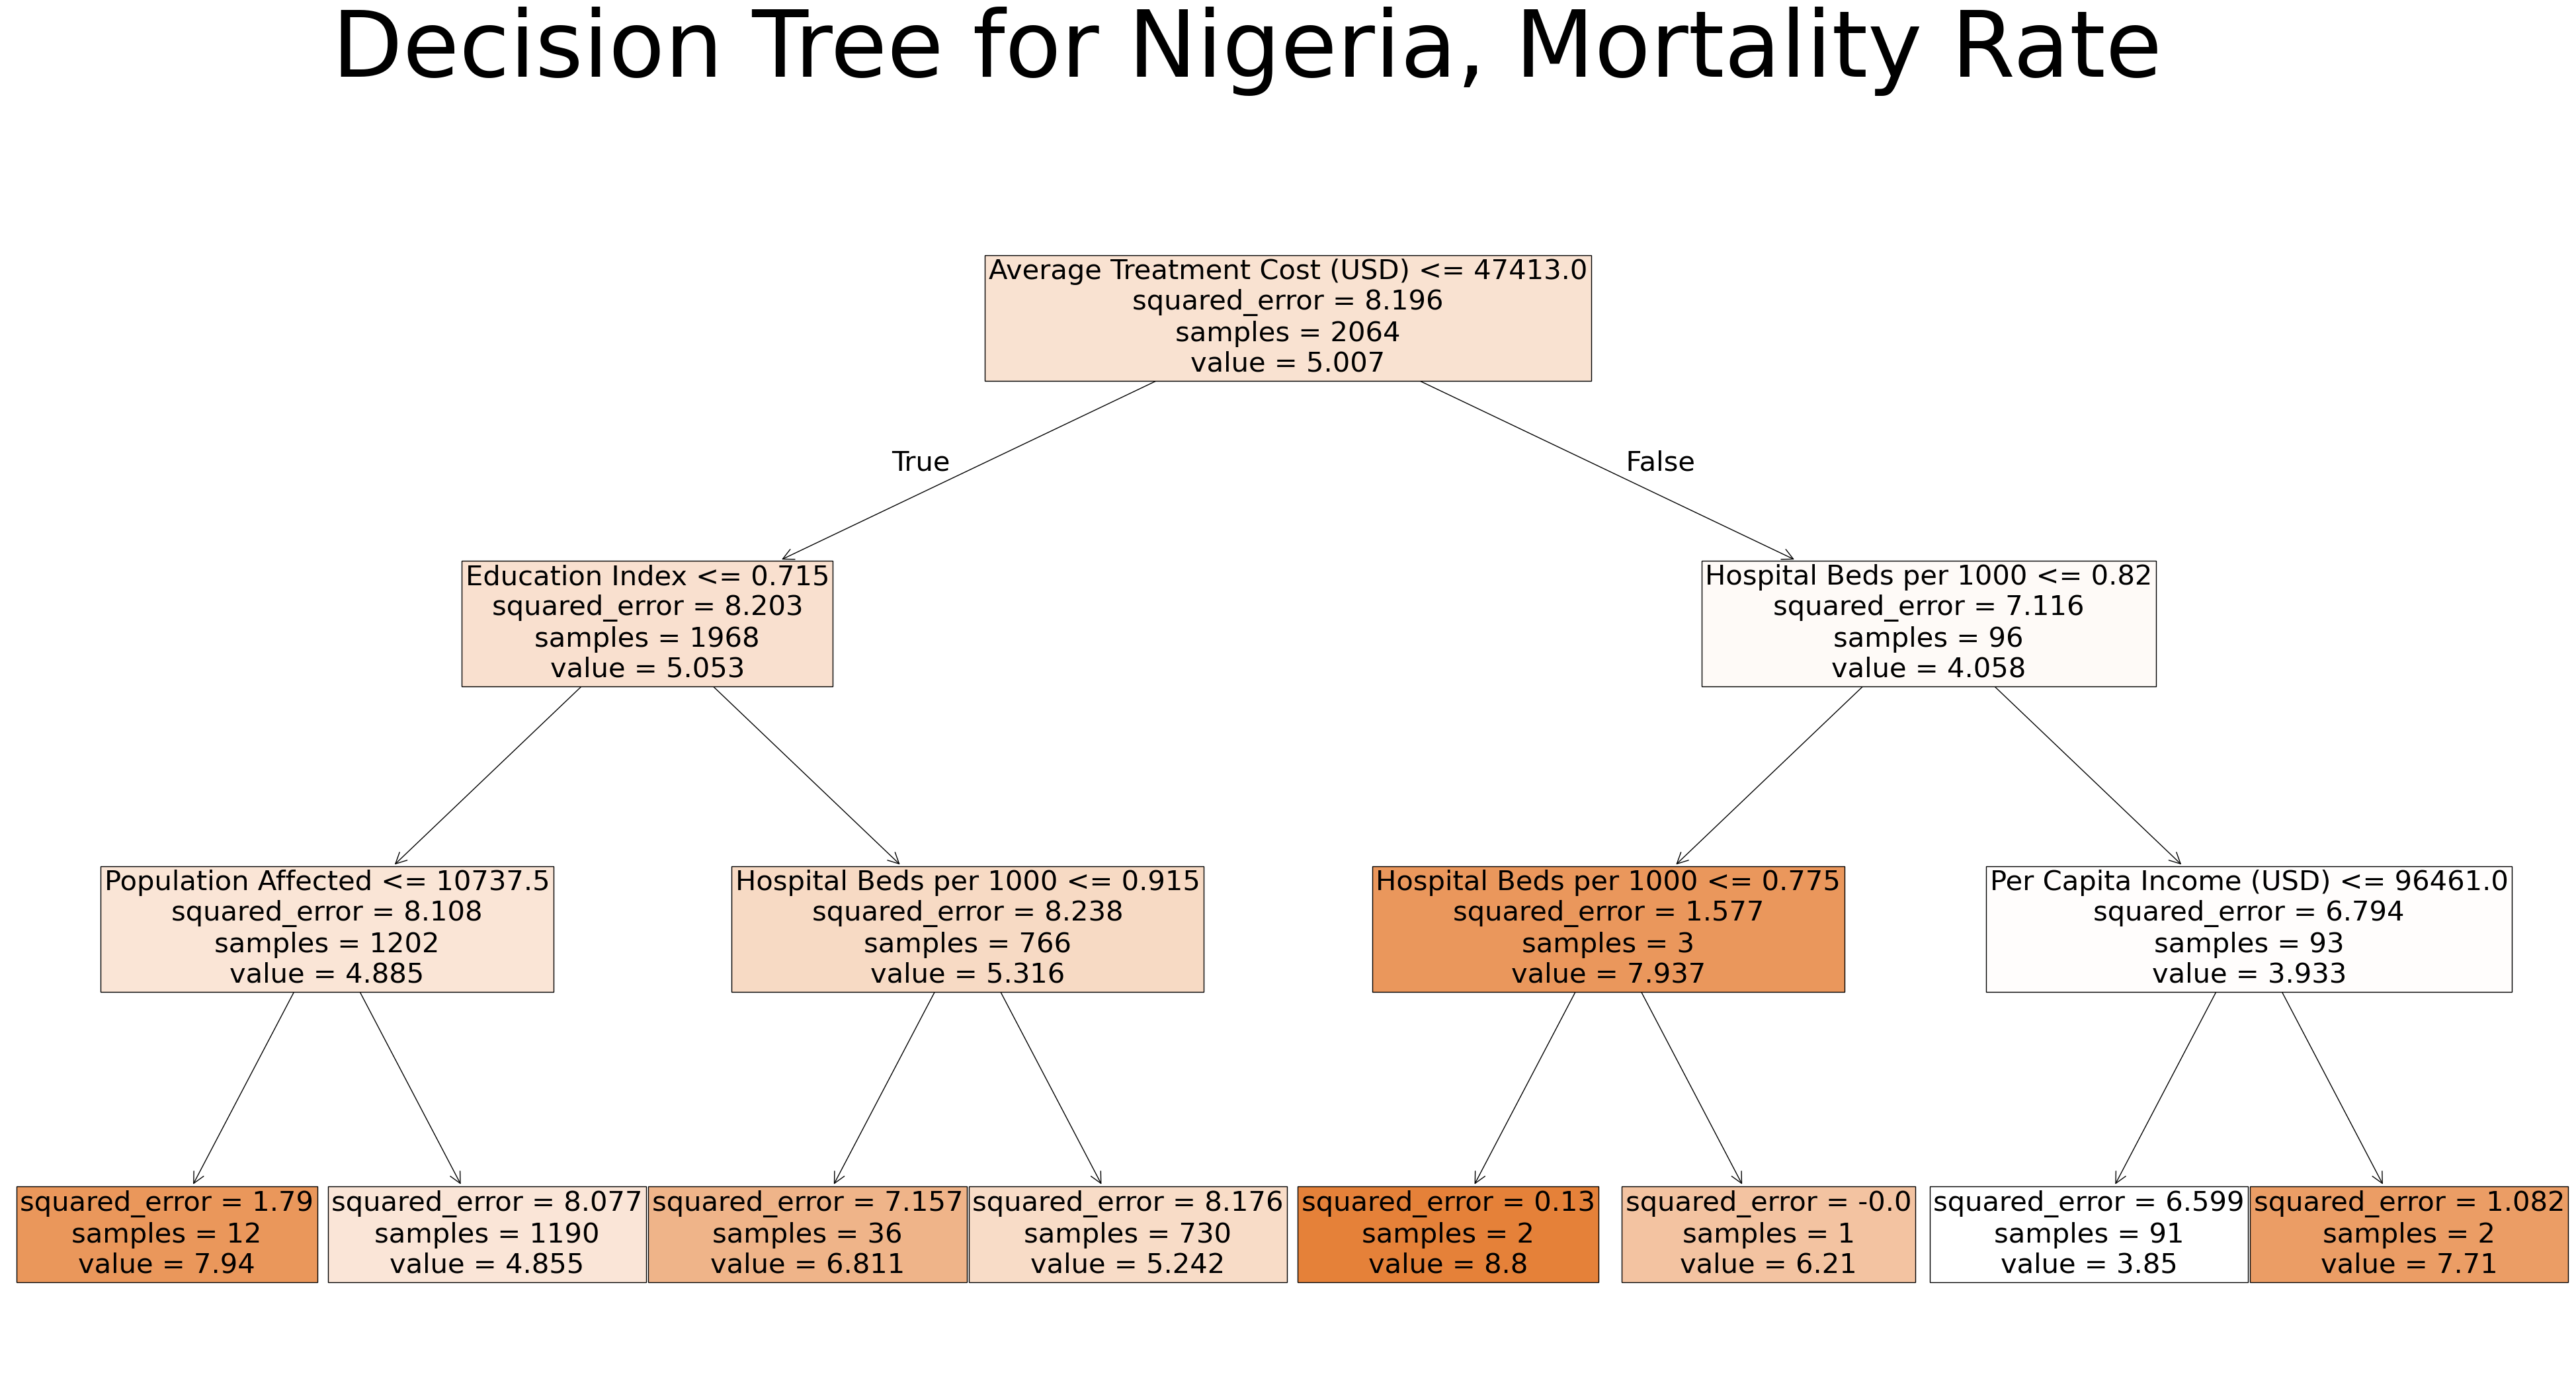

In [78]:
plt.figure(figsize=(50, 24))
plt.suptitle("Decision Tree for Nigeria, Mortality Rate", fontsize=100)
plot_tree(model, feature_names=X_test_nigeria_mortality.columns, fontsize=30, filled=True)
plt.show()

In [79]:
# Now more quickly for the US versions.

In [80]:
model.fit(X_train_us_incidence, y_train_us_incidence)
y_pred_us_incidence = model.predict(X_test_us_incidence)
y_pred_us_incidence = pd.DataFrame(y_pred_us_incidence)
y_test_us_incidence = y_test_us_incidence.reset_index(drop=True)
y_pred_us_incidence.rename(columns={0: 'Incidence Rate (%)'}, inplace=True)
mse_us_incidence = ((y_pred_us_incidence - y_test_us_incidence)**2).mean()
mse_us_incidence

Incidence Rate (%)    18.650828
dtype: float64

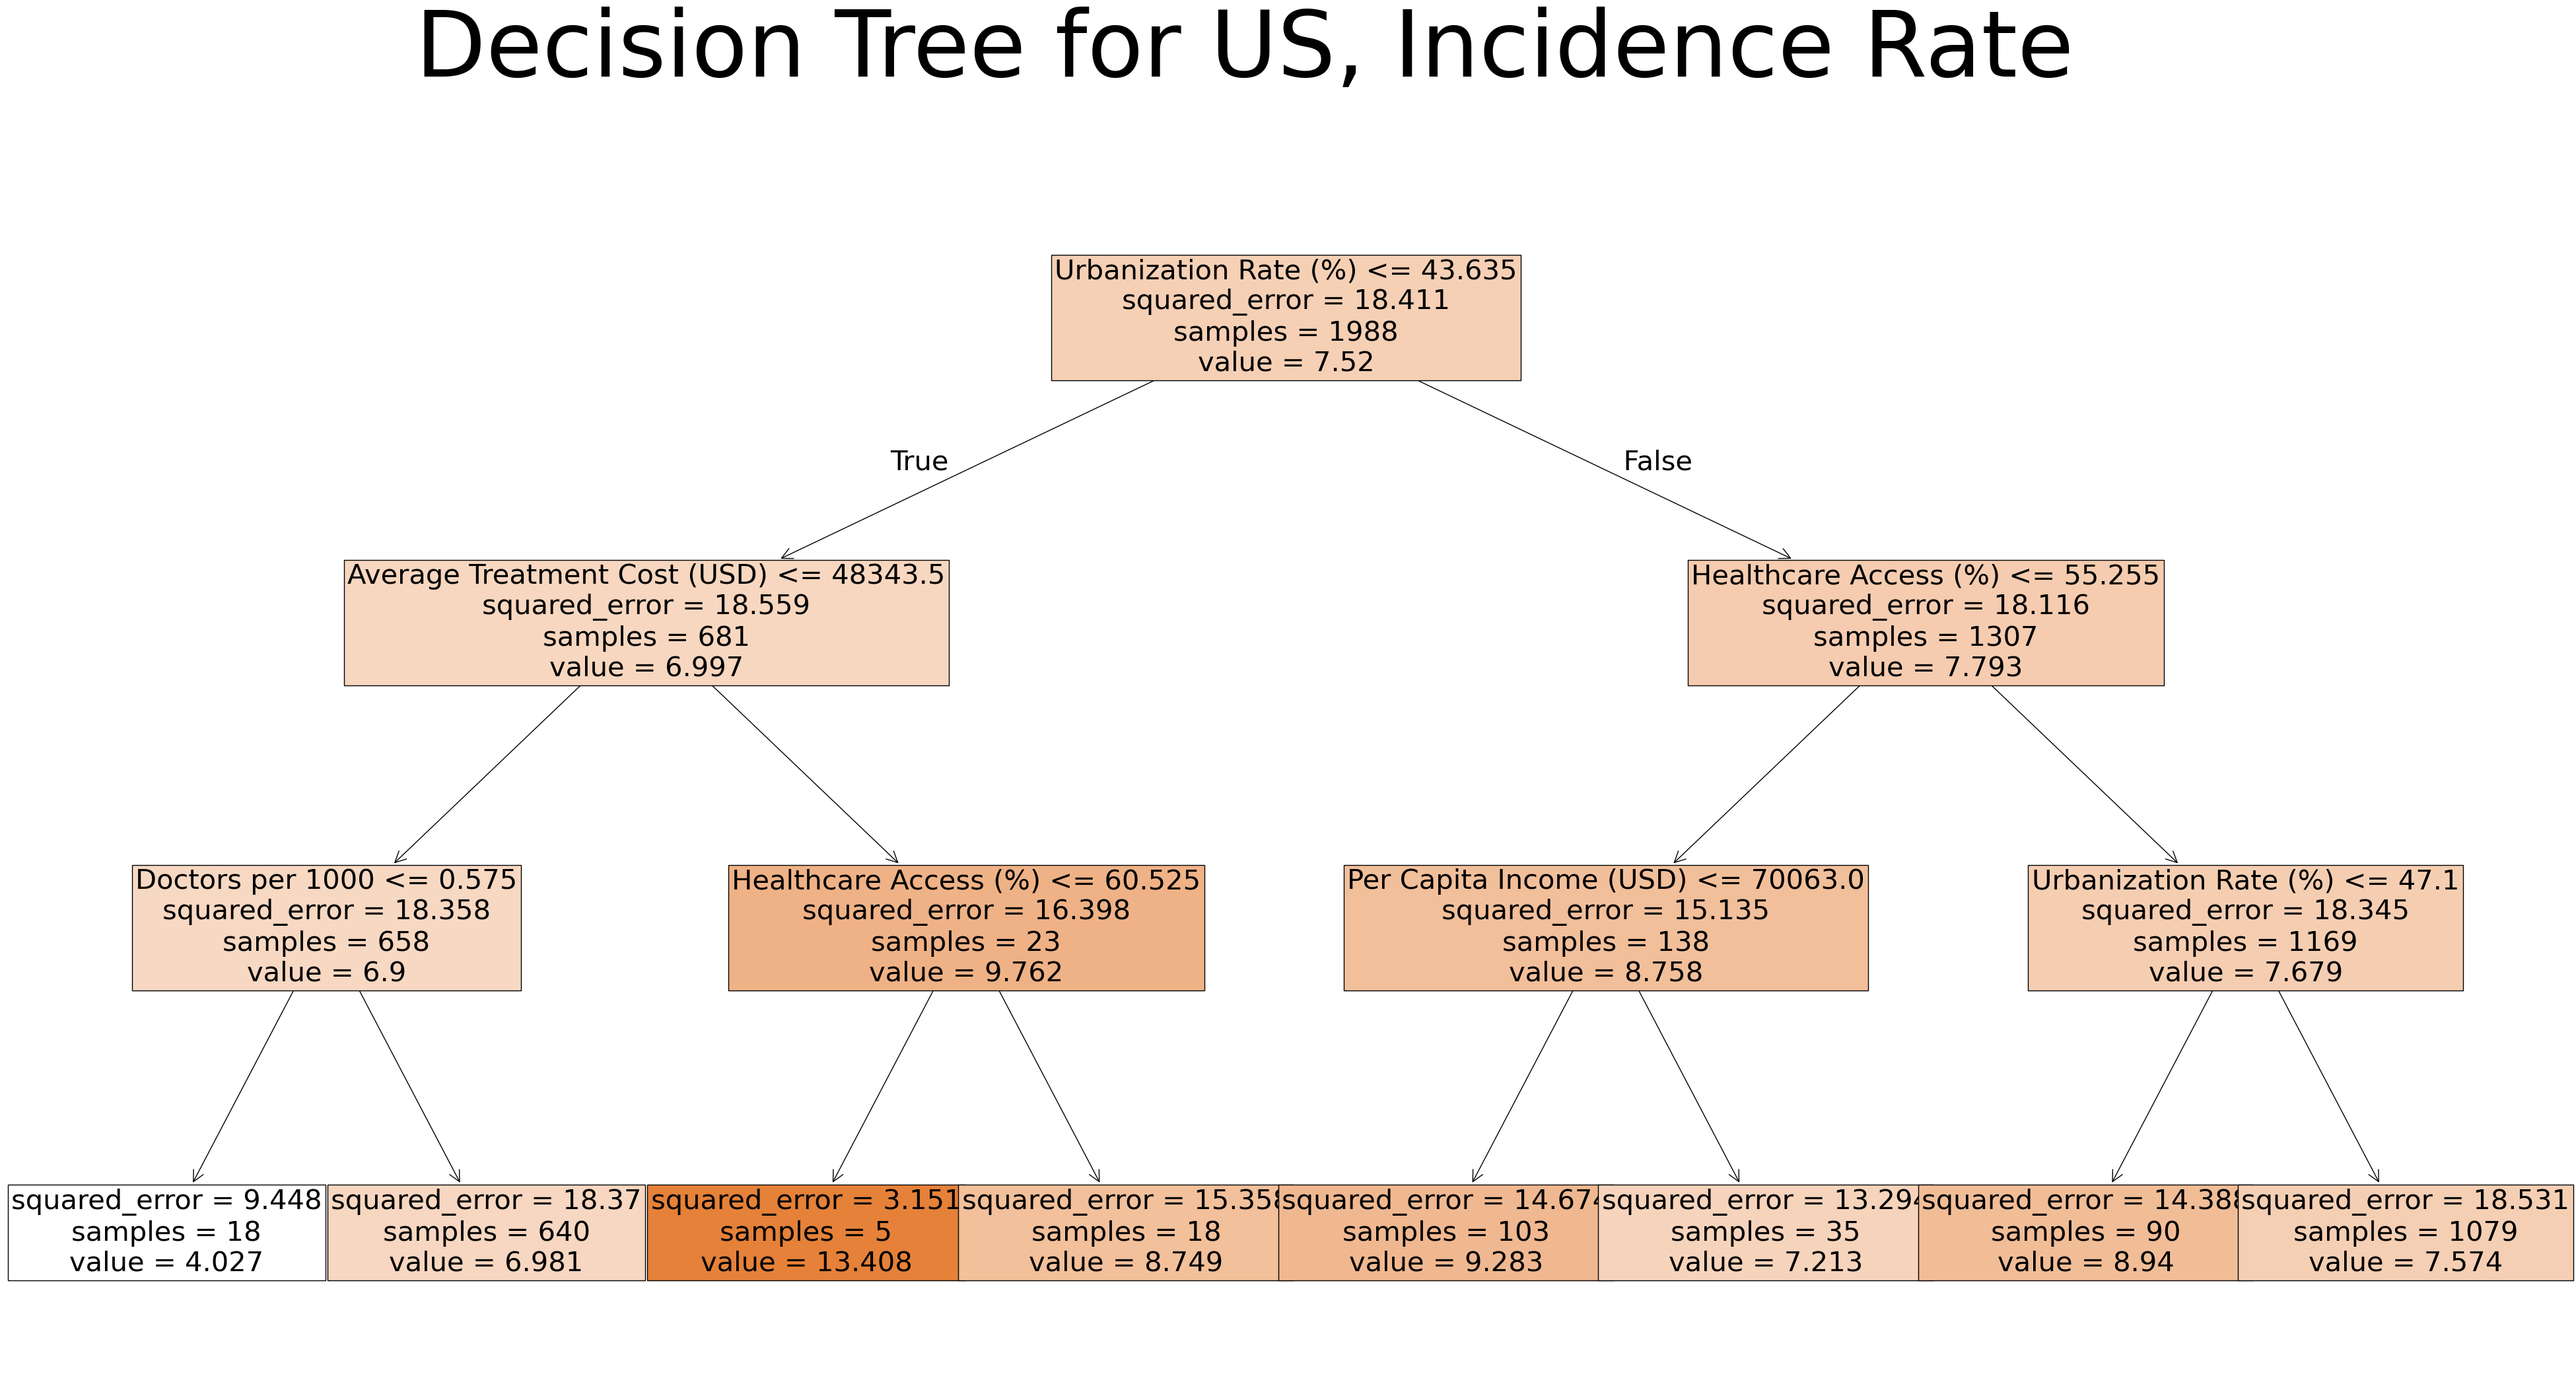

In [81]:
plt.figure(figsize=(50, 24))
plt.suptitle("Decision Tree for US, Incidence Rate", fontsize=100)
plot_tree(model, feature_names=X_test_us_incidence.columns, fontsize=30, filled=True)
plt.show()

In [82]:
model.fit(X_train_us_mortality, y_train_us_mortality)
y_pred_us_mortality = model.predict(X_test_us_mortality)
y_pred_us_mortality = pd.DataFrame(y_pred_us_mortality)
y_test_us_mortality = y_test_us_mortality.reset_index(drop=True)
y_pred_us_mortality.rename(columns={0: 'Mortality Rate (%)'}, inplace=True)
mse_us_mortality = ((y_pred_us_mortality - y_test_us_mortality)**2).mean()
mse_us_mortality

Mortality Rate (%)    8.783833
dtype: float64

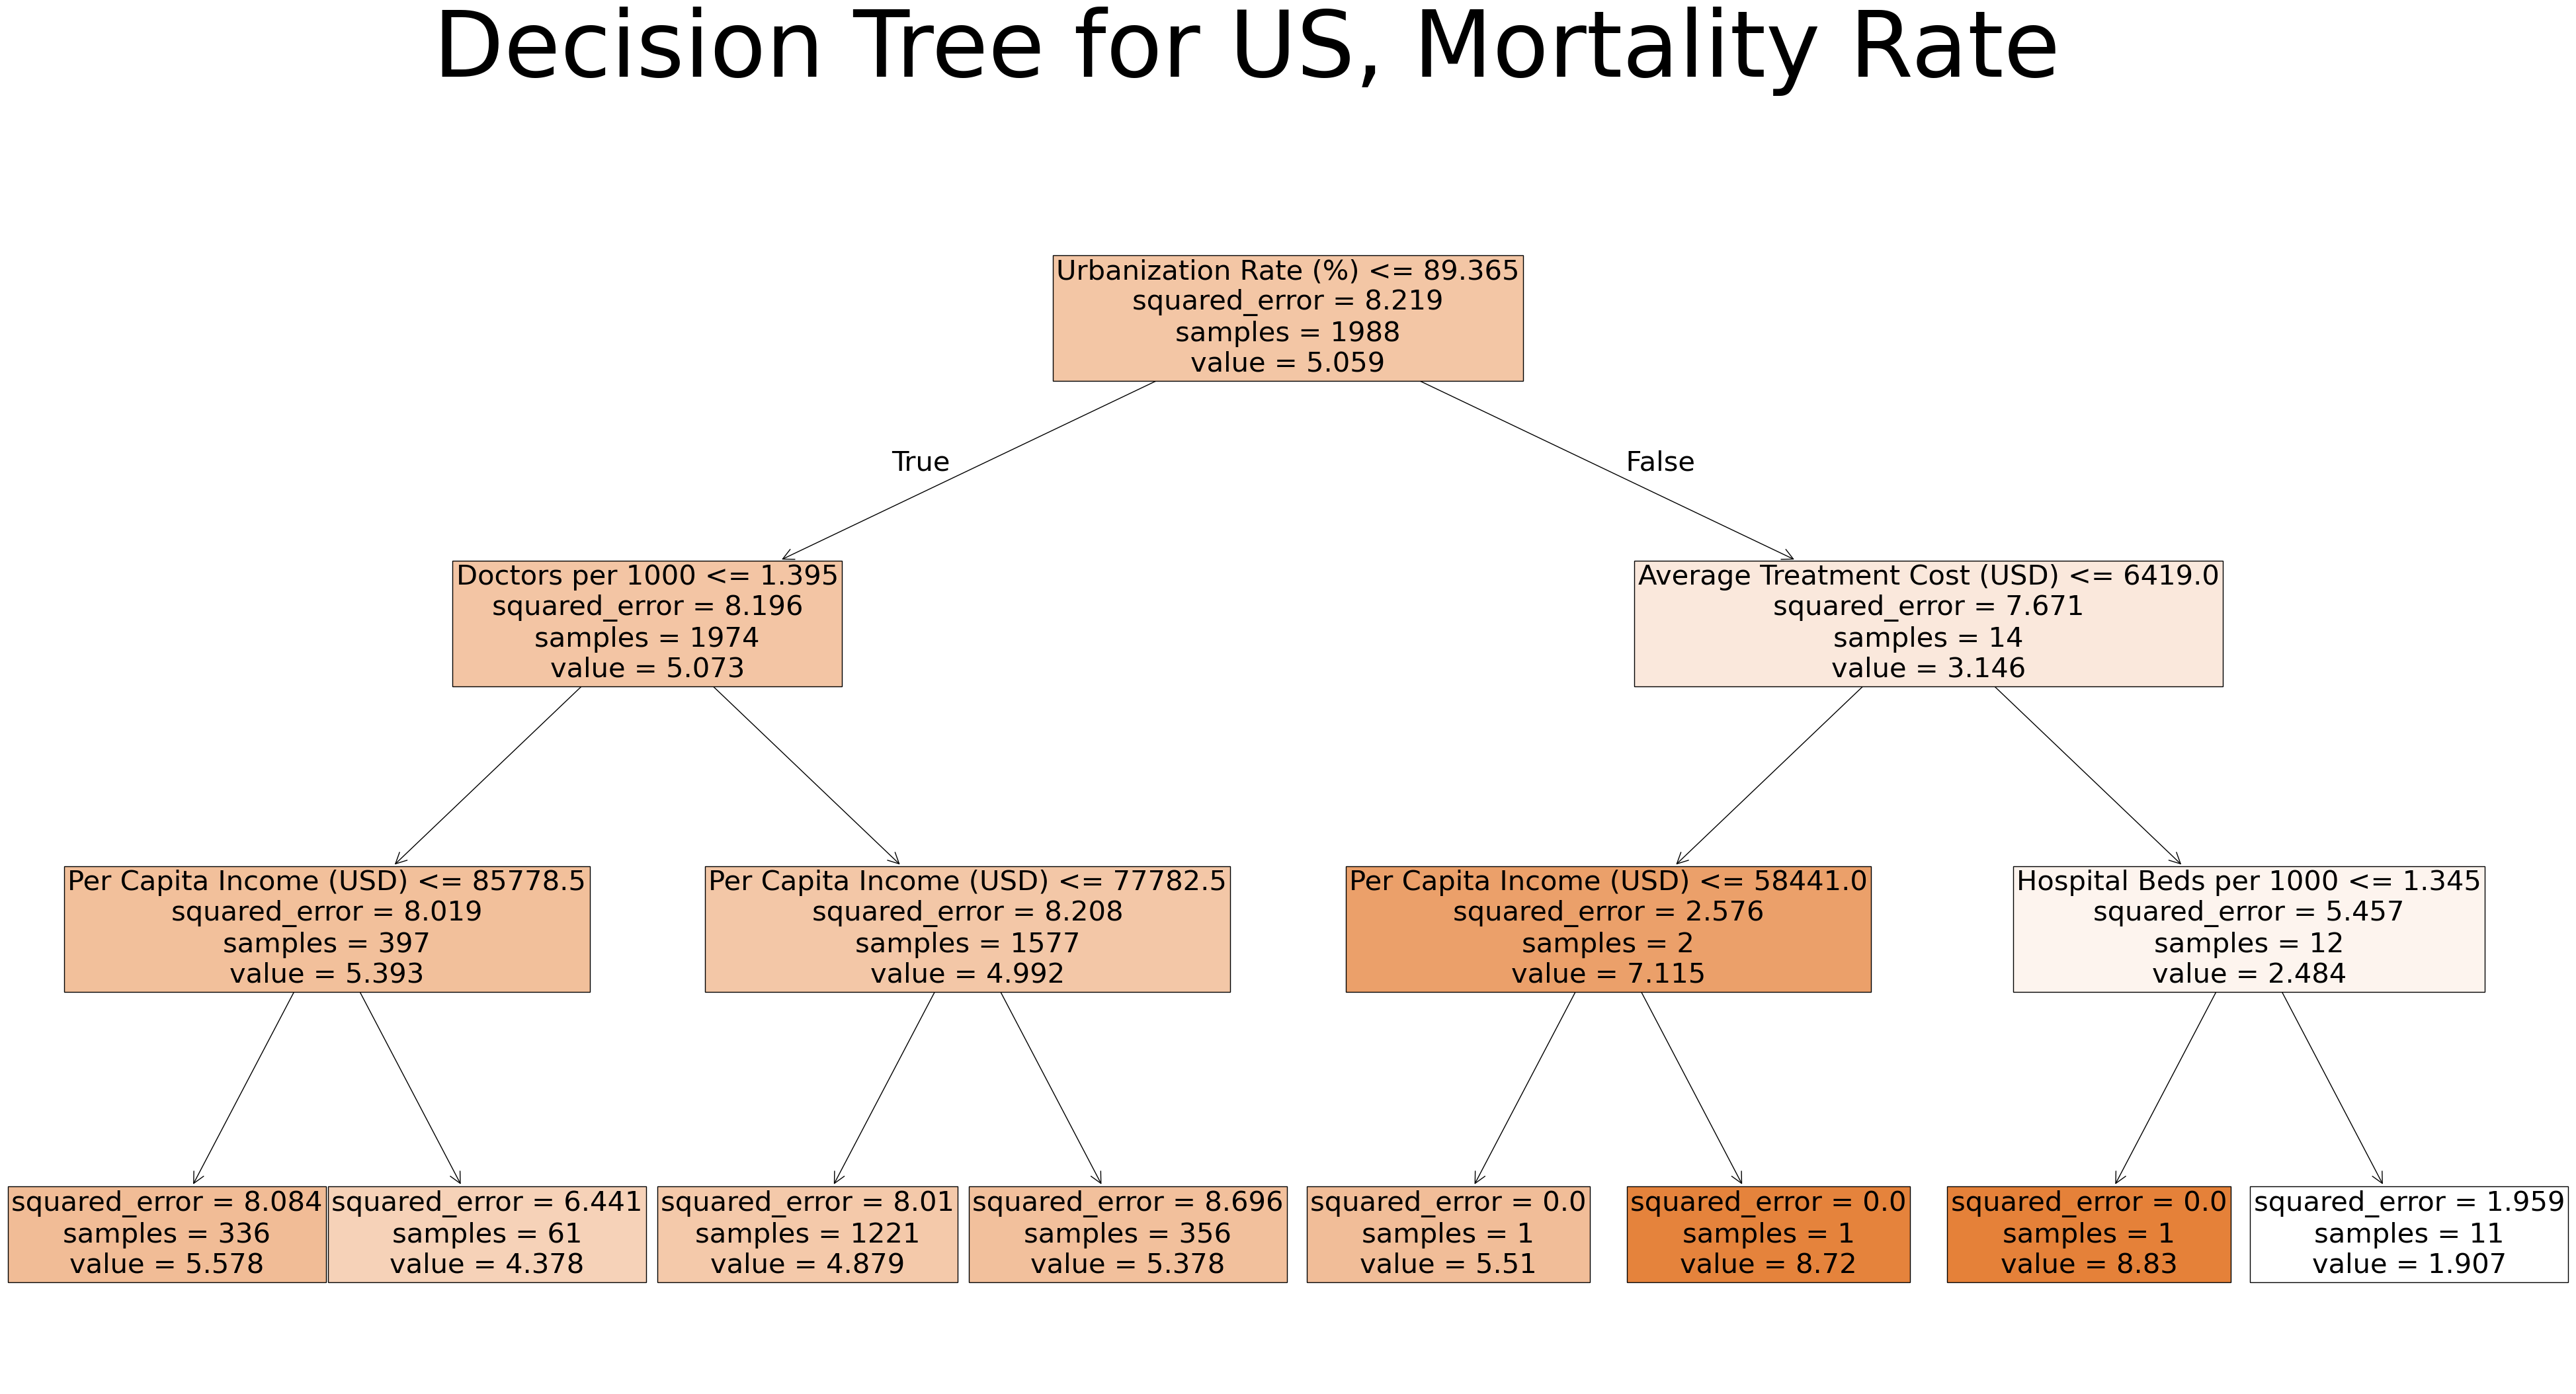

In [83]:
plt.figure(figsize=(50, 24))
plt.suptitle("Decision Tree for US, Mortality Rate", fontsize=100)
plot_tree(model, feature_names=X_test_us_mortality.columns, fontsize=30, filled=True)
plt.show()

In [84]:
# Now I want to do a simple regression on outcomes from the cost of treatment.  I'm interested
# in the effect on mortality rate, recovery rate, and improvement in 5 years based on healthcare
# access, doctors per 1000, hospital beds per 1000, and average treatment cost.  

In [85]:
X = ghs_us_zika[['Healthcare Access (%)', 'Doctors per 1000', 'Hospital Beds per 1000', 
                 'Average Treatment Cost (USD)']]
y1 = ghs_us_zika['Mortality Rate (%)']
y2 = ghs_us_zika['Recovery Rate (%)']
y3 = ghs_us_zika['Improvement in 5 Years (%)']

In [86]:
from sklearn.linear_model import LinearRegression
model1 = LinearRegression().fit(X, y1)
model2 = LinearRegression().fit(X, y2)
model3 = LinearRegression().fit(X, y3)

In [87]:
print("R²:", model1.score(X, y1))
print("Coefficients:", model1.coef_)
print("Intercept:", model1.intercept_)

R²: 0.0010493727372754558
Coefficients: [-3.30608542e-03 -3.19462775e-02  1.63083772e-02 -3.69763645e-06]
Intercept: 5.407313139583771


In [88]:
print("R²:", model2.score(X, y2))
print("Coefficients:", model2.coef_)
print("Intercept:", model2.intercept_)

R²: 0.00035220130684787687
Coefficients: [ 1.67740594e-02  2.97532543e-02 -1.40366891e-02 -6.66314699e-06]
Intercept: 73.54268693524078


In [89]:
print("R²:", model3.score(X, y3))
print("Coefficients:", model3.coef_)
print("Intercept:", model3.intercept_)

R²: 0.0004726309800981987
Coefficients: [ 3.71423119e-03  9.93446126e-03 -3.23987464e-03 -2.07252108e-06]
Intercept: 4.782264401375836


In [90]:
X_2 = ghs_nigeria_zika[['Healthcare Access (%)', 'Doctors per 1000', 'Hospital Beds per 1000', 
                 'Average Treatment Cost (USD)']]
y4 = ghs_nigeria_zika['Mortality Rate (%)']
y5 = ghs_nigeria_zika['Recovery Rate (%)']
y6 = ghs_nigeria_zika['Improvement in 5 Years (%)']

In [91]:
model4 = LinearRegression().fit(X_2, y4)
model5 = LinearRegression().fit(X_2, y5)
model6 = LinearRegression().fit(X_2, y6)

In [92]:
print("R²:", model4.score(X_2, y4))
print("Coefficients:", model4.coef_)
print("Intercept:", model4.intercept_)

R²: 0.004135605717062729
Coefficients: [ 1.12853275e-03  9.81222738e-02 -4.62227932e-02 -3.04055213e-06]
Intercept: 4.942507828485006


In [93]:
print("R²:", model5.score(X_2, y5))
print("Coefficients:", model5.coef_)
print("Intercept:", model5.intercept_)

R²: 0.00429008959547883
Coefficients: [ 4.15039559e-02  4.14472970e-01  1.53739738e-01 -1.49128258e-05]
Intercept: 69.90276078346443


In [94]:
print("R²:", model6.score(X_2, y6))
print("Coefficients:", model6.coef_)
print("Intercept:", model6.intercept_)

R²: 0.001900770265980234
Coefficients: [ 5.31437287e-03 -3.40806080e-02  2.89294548e-02  2.17468407e-06]
Intercept: 4.495488849236661
